# 06 Prophet Time-Series Forecasting

## Goal
Use Prophet to analyze time-based demand patterns and forecast future grocery demand.

## Input
`data/processed_demand_data.csv`

## Notes
Prophet helps identify:
- overall demand trend
- daily seasonality
- weekly seasonality

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

In [2]:
demand_data = pd.read_csv("/Users/ayu/Desktop/AI_Grocery_Demand_Forecasting/notebooks/data/processed_demand_data.csv")
demand_data.head()

,day_of_week,hour,dept_name,demand,is_weekend,hour_sin,hour_cos,dept_encoded,log_demand
0,0,0,alcohol,52,1,0.0,1.0,0,3.970292
1,0,0,babies,400,1,0.0,1.0,1,5.993961
2,0,0,bakery,1301,1,0.0,1.0,2,7.171657
3,0,0,beverages,2970,1,0.0,1.0,3,7.996654
4,0,0,breakfast,721,1,0.0,1.0,4,6.582025


## 1. Prepare Time-Series Data

Prophet requires:
- ds → datetime
- y → value to forecast

In [3]:
ts_data = (
    demand_data
    .groupby(['day_of_week', 'hour'])['demand']
    .sum()
    .reset_index()
)

ts_data.head()

,day_of_week,hour,demand
0,0,0,38876
1,0,1,22523
2,0,2,12725
3,0,3,8851
4,0,4,8372


In [4]:
ts_data['ds'] = pd.to_datetime(
    ts_data['day_of_week'].astype(str) + " " +
    ts_data['hour'].astype(str) + ":00",
    format="%w %H:%M"
)

ts_data = ts_data[['ds', 'demand']]
ts_data = ts_data.rename(columns={'demand': 'y'})

ts_data.head()

,ds,y
0,1900-01-01 00:00:00,38876
1,1900-01-01 01:00:00,22523
2,1900-01-01 02:00:00,12725
3,1900-01-01 03:00:00,8851
4,1900-01-01 04:00:00,8372


## 2. Train Prophet Model

In [5]:
model_prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True
)

model_prophet.fit(ts_data)

04:12:25 - cmdstanpy - INFO - Chain [1] start processing
04:12:25 - cmdstanpy - INFO - Chain [1] done processing


## 3. Create Future Time Periods

In [6]:
future = model_prophet.make_future_dataframe(
    periods=48,
    freq='H'
)

future.head()

,ds
0,1900-01-01 00:00:00
1,1900-01-01 01:00:00
2,1900-01-01 02:00:00
3,1900-01-01 03:00:00
4,1900-01-01 04:00:00


## 4. Generate Forecast

In [7]:
forecast = model_prophet.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
67,1900-01-03 19:00:00,140128.319659,76583.445362,209572.172847
68,1900-01-03 20:00:00,116900.135665,53381.057690,186829.961213
69,1900-01-03 21:00:00,106040.786021,37523.434459,169381.658407
70,1900-01-03 22:00:00,90054.802959,23487.928880,159092.071107
71,1900-01-03 23:00:00,63051.079063,-5262.416947,135571.185180


## 5. Prevent Negative Demand

In [8]:
forecast['yhat'] = forecast['yhat'].clip(lower=0)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
forecast['yhat_upper'] = forecast['yhat_upper'].clip(lower=0)

## 6. Forecast Plot

/Users/ayu/anaconda3/lib/python3.11/site-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/Users/ayu/anaconda3/lib/python3.11/site-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


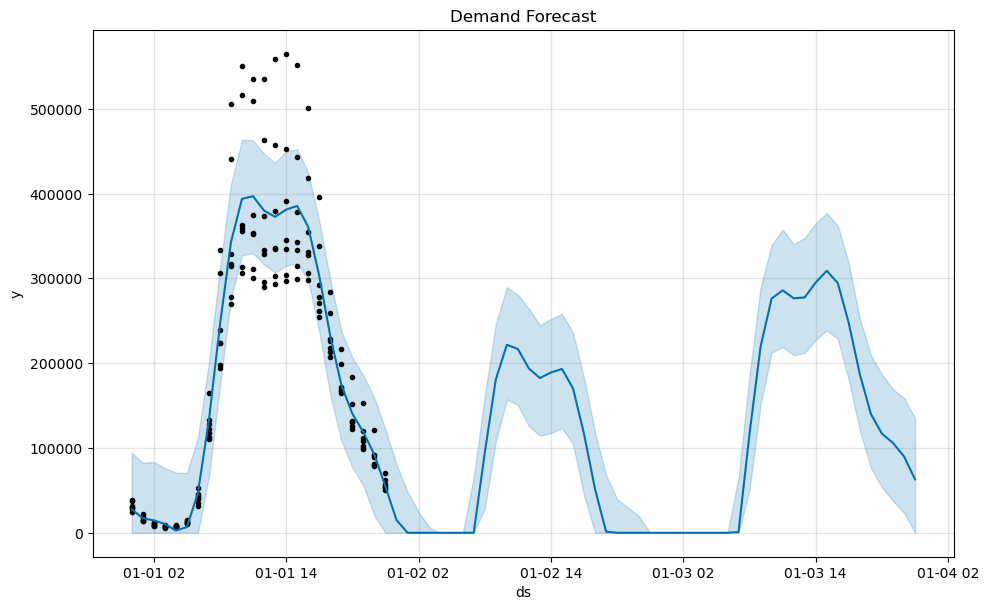

In [9]:
model_prophet.plot(forecast)
plt.title("Demand Forecast")
plt.show()

## 7. Seasonality Components

/Users/ayu/anaconda3/lib/python3.11/site-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/Users/ayu/anaconda3/lib/python3.11/site-packages/prophet/plot.py:397: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  artists += ax.plot(df_y['ds'].dt.to_pydatetime(), seas[name], ls='-',
/Users/ayu/anaconda3/lib/python3.11/site-packages/prophet/plot.py:401: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain

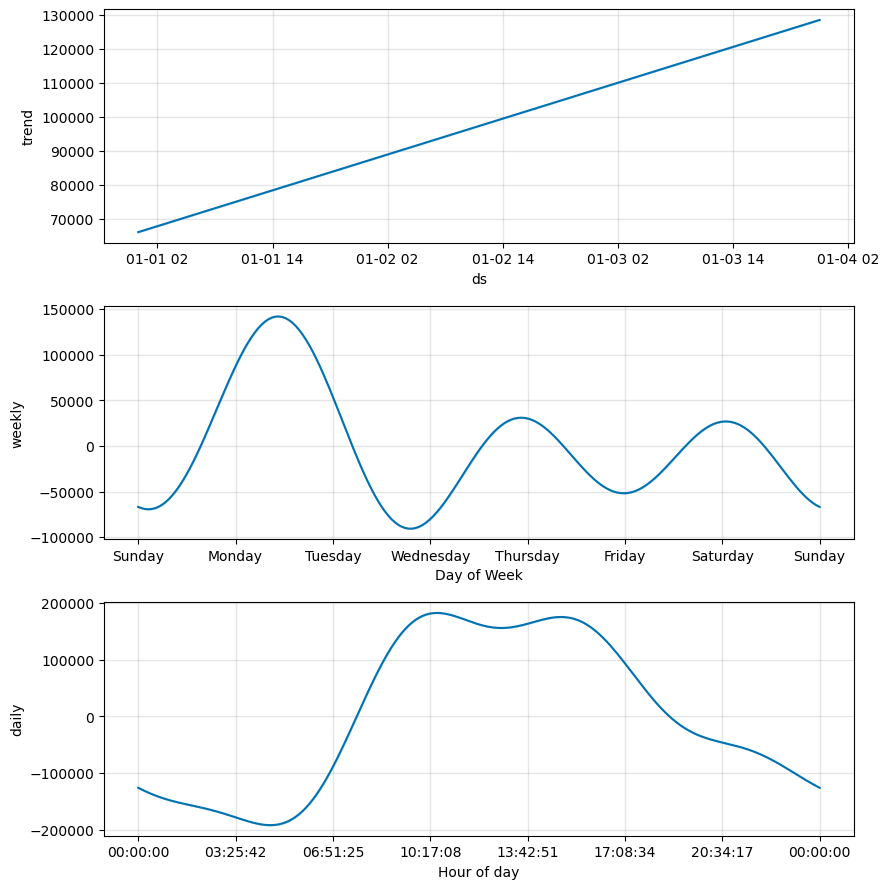

In [10]:
model_prophet.plot_components(forecast)
plt.show()

## Key Insights

Daily Seasonality
- demand peaks around late morning and early afternoon

Weekly Seasonality
- demand fluctuates across weekdays

Operational Implications
- peak grocery demand occurs mid-day
- overnight demand remains very low

# Project Summary

Pipeline built in this project:

1. Data loading and cleaning
2. Feature engineering
3. Demand pattern analysis
4. Random Forest forecasting
5. XGBoost forecasting
6. Prophet time-series analysis

This workflow demonstrates how demand forecasting models can support
inventory planning and supply chain decision-making.